# Computational Neuroscience Workshop

This notebook contains three short, hands-on modules:

 **Module 1** - Single LIF neuron (Brian2)\
 **Module 2** - 3-neuron microcircuit (Brian2)\
 **Module 3** - EEG playground (load pre-generated data 'sim_eeg.npy')

Required Python packages:\
Brian2 and Matplotlib

## Module 1 - Single LIF neuron (Brian2)

Goal:\
To simulate a simple _leaky integrate-and-fire_ neuron using _Brian2_.\
Simulation runs for 500ms and will return the mebrane potential and action potentials.

In [1]:
# %%
# pip install brian2

In [2]:
# %%
# Imports (Module 1 & 2)
import matplotlib.pyplot as plt
from brian2 import *
import brian2.numpy_ as np

In [ ]:
# %%
# Module 1 - Parameters
# ---------------------

# Edit those lines to change neuron parameters:
I_ext = 0.5 * namp             # External current amplitude
tau_m = 20.0 * ms              # Membrane time constant
v_r = -65.0 * mV               # Resting potential
v_reset = -65.0 * mV           # Potentiel after spiking (= AP fired)
v_th = -50.0 * mV              # Threshold for spiking
refractory_period = 3.0 * ms  # Refractory period to allow spike decay
R = 100.0 * Mohm               # Membranar resistance
sigma = 2.0 * mV               # Noise intensity

# Define time-varying input current (pulses from 100-200 ms and 300-400 ms)
I_ext_values = np.zeros(500) * nA
I_ext_values[100:200] = I_ext
I_ext_values[300:400] = I_ext
I_ext_func = TimedArray(I_ext_values, dt=1*ms)

LIF equation: 
$$\frac{dV}{dt} = \frac{-(V - V_{rest}) + R \times I_{ext}}{\tau_m} + \sigma \times \xi \times \sqrt{\tau_m}$$

**Notes:**
- Try to change '```I_ext```' to adapt the strengh of the external current application;
- Change '```tau_m```' to see how membrane integers;
- Change '```v_th```' to ease action potential firing;

In [ ]:
# %%
# Module 1 - Equations & model
# ----------------------------
start_scope()  # Essentiel to avoid any conflit with Brian2

eqs = """
dv/dt = (-(v - v_r) + R * I_ext_func(t)) / tau_m + sigma * xi * tau_m ** -0.5: volt (unless refractory)
"""

# Creat a single neuron
G = NeuronGroup(1, eqs, threshold='v>v_th', reset='v = v_reset',
               refractory=refractory_period, method='euler')
G.v = v_r

# Monitors - Objects that keep track of what's happening
state_mon = StateMonitor(G, 'v', record=True)
spike_mon = SpikeMonitor(G, variables='v')

# Run simulation for 500ms
dur = 500
print(f"Ongoing simulation for {dur}ms...\n")
run(dur*ms)
print("Simulation done!")

Ongoing simulation for 500ms...

Simulation done!


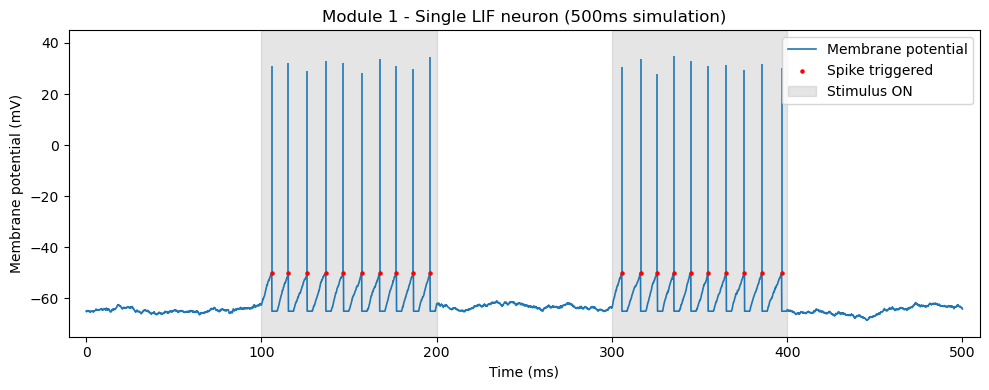

In [ ]:
# %%
# Module 1 - Plotting
# -------------------

fig, ax = plt.subplots(figsize=(10, 4))

# 1. Plot the membrane potential
ax.plot(state_mon.t/ms, state_mon.v[0]/mV, lw=1.2, color='tab:blue', label='Membrane potential')

# 2. Draw the vertical action potentials
    # Just for visual purposes, we draw a line from the threshold up to +30mV-ish for every recorded spike
num_spikes = len(spike_mon.t)
random_peaks = np.random.normal(loc=30.0, scale=3.0, size=num_spikes)  # Randomize spike heights around 30mV
ax.vlines(spike_mon.t/ms, ymin=v_th/mV, ymax=random_peaks, color='tab:blue', lw=1.2)

# Optional: keep red dots to mark the threshold crossing clearly
ax.scatter(spike_mon.t/ms, np.ones(len(spike_mon.t))*(v_th/mV),
            color='red', s=5, zorder=5, label='Spike triggered')

# Optional: add a shaded background to show when the stimulus is active
ax.axvspan(100, 200, color='grey', alpha=0.2, label='Stimulus ON')
ax.axvspan(300, 400, color='grey', alpha=0.2)

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Membrane potential (mV)')
ax.set_title('Module 1 - Single LIF neuron (500ms simulation)')
ax.set_ylim(v_r/mV - 10, max(random_peaks) + 10)  # Set y-limits to show resting potential and spikes clearly
ax.set_xlim(-10, 510)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Module 2 - 3-neuron microcircuit (Brian2)

Goal:\
Reccurent minimal microcircuit with 2 excitatory (E) LIF neurons and 1 inhibitor (I).\
You can change one or two synaptic weights.
Connection : 
- E → E (recurrent)
- E → I
- I → E (inhibitory feedback)

We'll create a raster plot and a population estimate.

In [3]:
# %%
# Module 2 - Network of neurons
# ----------------------------

start_scope()

# Simulation parameters
sim_dur = 1_000.0 * ms  # runs for one second

# Shared neuron parameters
tau_m = 20.0 * ms
v_rest = -65.0 * mV
v_reset = -65.0 * mV
v_tresh = -50.0 * mV
refractory_period = 5.0 * ms
R = 100.0 * Mohm
sigma = 2.5 * mV

# External current parameters - Change them and see what's happening!
I_e = 0.22 * nA  # External current for excitatory neurons
I_i = 0.18 * nA  # External current for inhibitory neurons

In [16]:
# %%
# Module 2 - Equations & model
# ----------------------------

# Creation of neuron groups: 2 Excitatory and 1 Inhibitory
eqs = '''
dv/dt = (-(v - v_rest) + R*I_inj) / tau_m + sigma * xi * tau_m ** -0.5: volt (unless refractory)
I_inj : amp
'''

E = NeuronGroup(2, eqs, threshold='v>v_tresh', reset='v=v_rest',
                refractory=refractory_period, method='euler')
I = NeuronGroup(1, eqs, threshold='v>v_tresh', reset='v=v_rest',
                refractory=refractory_period, method='euler')

# Initialisation of membrane potentials with slight random heterogeneity to avoid perfect synchrony
E.v = v_rest + (np.random.rand(len(E)) - 0.5) * 5.0 * mV  # Add random noise to initial potentials
I.v = v_rest + (np.random.rand(len(I)) - 0.5) * 5.0 * mV  # Add random noise to initial potentials

# Define injected currents for each group
E.I_inj = I_e
I.I_inj = I_i 

In [17]:
# %%
# Module 2 - Synapses & simulation
# ----------------------------

# Synaptic weights (to modify) - Change those values and see how the network dynamics change!
w_EE = 1.5 * mV   # weights E --> E 
w_EI = 2.0 * mV   # weights E --> I 
w_IE = -3.0 * mV  # weights I --> E (negative for inhibition)

# Synapses creation 
    # E --> E (recurrent, connected to avoid autapse)
S_EE = Synapses(E, E, on_pre='v_post += w_EE')
S_EE.connect(condition='i!=j')  # No autapse

    # E --> I 
S_EI = Synapses(E, I, on_pre='v_post += w_EI')
S_EI.connect()

    # I --> E (inhibition)
S_IE = Synapses(I, E, on_pre='v_post += w_IE')
S_IE.connect()

# Monitors
    # Spike monitors to record spike times
spike_mon_E = SpikeMonitor(E)
spike_mon_I = SpikeMonitor(I)

    # Population rate monitor to record firing rates and state monitor to record membrane potentials
state_mon_E = StateMonitor(E, 'v', record=True)
state_mon_I = StateMonitor(I, 'v', record=True)

    # Excitatory population rate monitor
rate_mon_E = PopulationRateMonitor(E)
rate_mon_I = PopulationRateMonitor(I)

# Launch the simulation
print(f"Ongoing simulation for {sim_dur}ms...\n")
run(sim_dur)
print("Simulation done!")

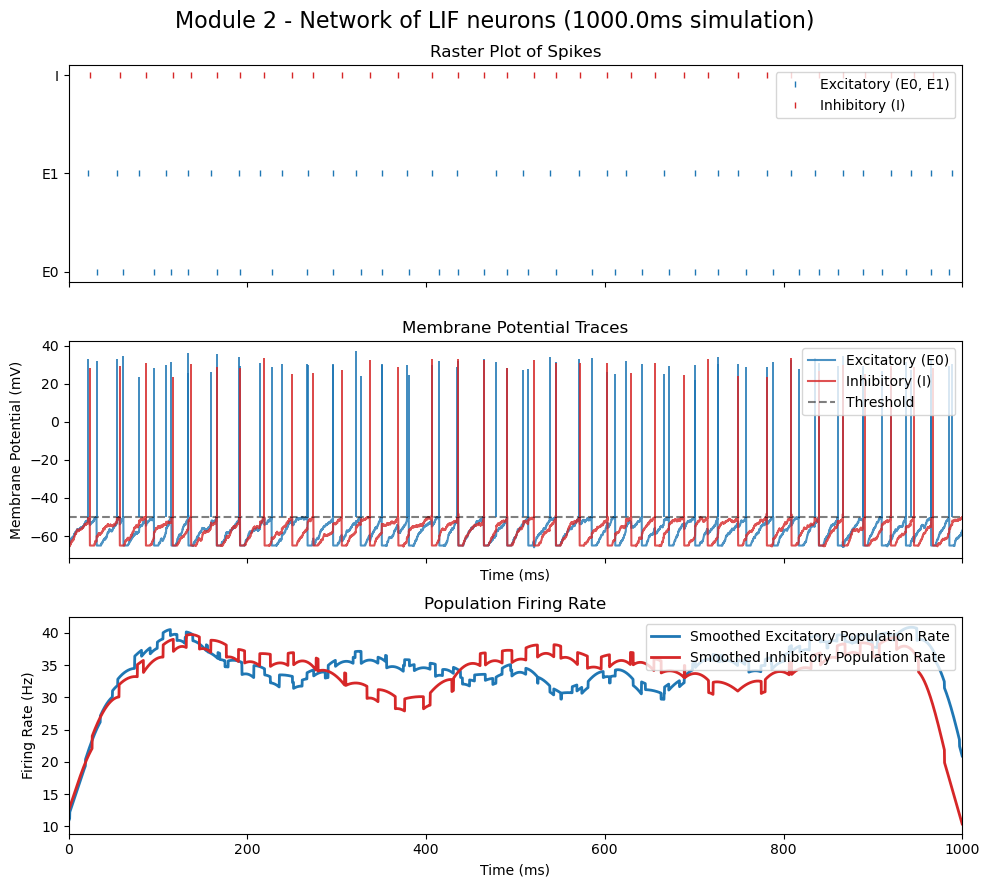

In [19]:
# %%
# Module 2 - Plots
# -------------------

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# Top plot: Raster plot of spikes
ax1.plot(spike_mon_E.t/ms, spike_mon_E.i, '|', markersize=5, color='tab:blue', label='Excitatory (E0, E1)')
ax1.plot(spike_mon_I.t/ms, spike_mon_I.i + 2, '|', markersize=5, color='tab:red', label='Inhibitory (I)')  # Offset I index for visualization
ax1.set_yticks([0, 1, 2])  # Set y-ticks to show neuron indices clearly
ax1.set_yticklabels(['E0', 'E1', 'I'])
ax1.set_title('Raster Plot of Spikes')
ax1.legend(loc='upper right')

# Middle plot: Membrane potential traces (The "why" behind the raster plot)
ax2.plot(state_mon_E.t/ms, state_mon_E.v[0]/mV, color='tab:blue', label='Excitatory (E0)', alpha=0.8)
ax2.plot(state_mon_I.t/ms, state_mon_I.v[0]/mV, color='tab:red', label='Inhibitory (I)', alpha=0.8)  # Offset I index for visualization
ax2.axhline(v_tresh/mV, color='k', linestyle='--', alpha=0.5, label='Threshold')  # Add threshold line for reference

    # Just for visual purposes, we draw a line from the threshold up to +30mV-ish for every recorded spike
num_spikes_e = len(spike_mon_E.t)
num_spikes_i = len(spike_mon_I.t)
random_peaks_e = np.random.normal(loc=30.0, scale=3.0, size=num_spikes_e)  # Randomize spike heights around 30mV
random_peaks_i = np.random.normal(loc=30.0, scale=3.0, size=num_spikes_i)  # Randomize spike heights around 30mV
ax2.vlines(spike_mon_E.t/ms, ymin=v_tresh/mV, ymax=random_peaks_e, color='tab:blue', lw=1.2)
ax2.vlines(spike_mon_I.t/ms, ymin=v_tresh/mV, ymax=random_peaks_i, color='tab:red', lw=1.2)

ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Membrane Potential (mV)')
ax2.set_title('Membrane Potential Traces')
ax2.legend(loc='upper right')
ax2.set_xlim(0, float(sim_dur/ms))

# Bottom plot: Population firing rate of excitatory neurons
    # We use a smoothed version of the population rate for better visualization
window_width = 30 * ms
smoothed_rate_e = rate_mon_E.smooth_rate(window='gaussian', width=window_width) / Hz
smoothed_rate_i = rate_mon_I.smooth_rate(window='gaussian', width=window_width) / Hz

ax3.plot(rate_mon_E.t/ms, smoothed_rate_e, color='tab:blue', lw=2, label='Smoothed Excitatory Population Rate')
ax3.plot(rate_mon_I.t/ms, smoothed_rate_i, color='tab:red', lw=2, label='Smoothed Inhibitory Population Rate')
ax3.set_xlabel('Time (ms)')
ax3.set_ylabel('Firing Rate (Hz)')
ax3.set_title('Population Firing Rate')
ax3.legend(loc='upper right')
ax3.set_xlim(0, float(sim_dur/ms))

fig.suptitle(f'Module 2 - Network of LIF neurons ({sim_dur/ms}ms simulation)', fontsize=16)

plt.tight_layout()
plt.show()

## Module 3 - Low-level analysis on EEG-like data

Objectif : Réaliser deux spectrogrammes comparatifs de traces EEG d'une activité cérébrale saine et d'une crise épileptique. 

Les données saines ont été génerées selon le modèle de Jansen et Rit (Jansen et al., 1995), tandis que les pathologiques ont toutes été génerées avec celui de Wendling (Wendling et al., 2002).

In [50]:
from scipy.signal import spectrogram
from mpl_toolkits.axes_grid1 import make_axes_locatable as mal

In [39]:
# Première étape, charger les données:
healthy = np.array(np.load("sim_eeg_4.npy"))
patho = np.array(np.load("sim_eeg_patho21.npy"))
data = np.load("simm_eeg_trace22.npy")
data_parameters = np.load("sim_eeg_param22.npz")

In [40]:
time = data_parameters["time"]
exc = data_parameters["A"]
slow_inh = data_parameters["B"]
fast_inh = data_parameters["G"]

In [5]:
fs = 1000                                       # sampling rate (Hz) | frequency at which data is saved
duration = 90.0                                 # seconds
n_samples = int(duration * fs)
t = np.linspace(0, duration, n_samples)
htime_vector = np.linspace(0, len(healthy)/fs, len(healthy))
ptime_vector = np.linspace(0, len(patho)/fs, len(patho))

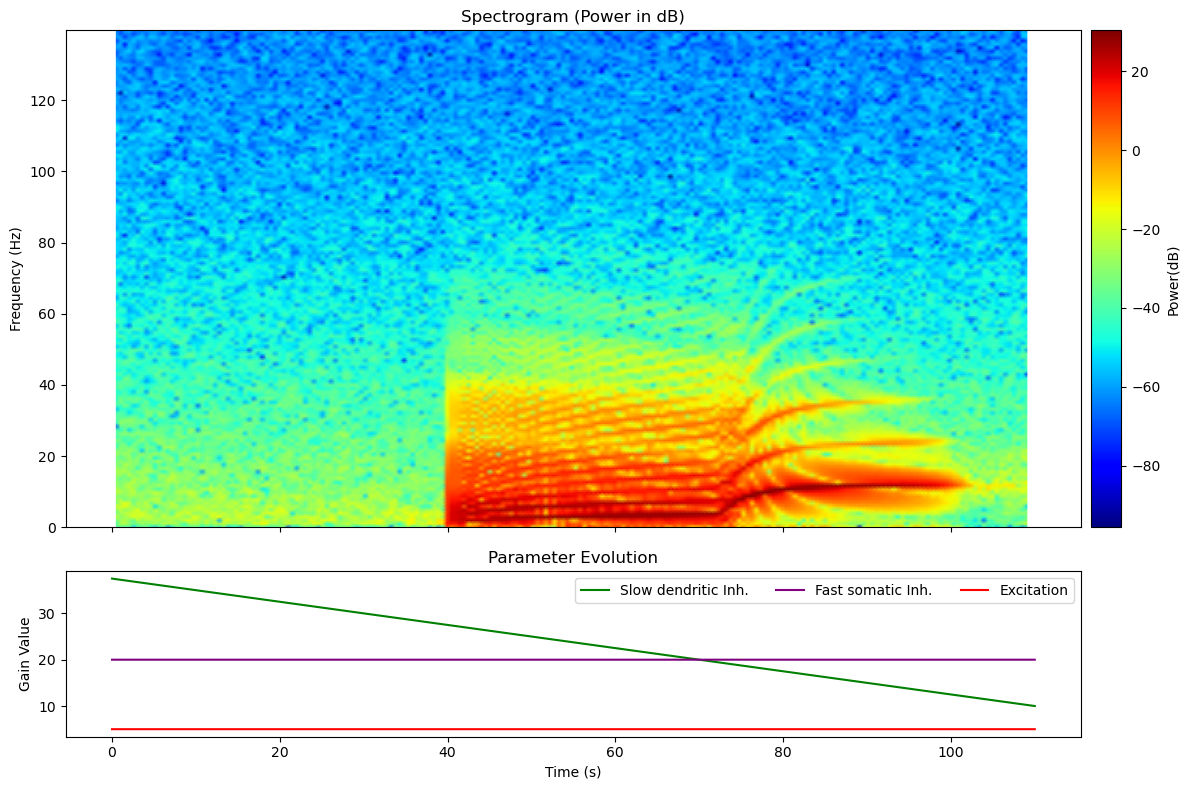

In [ ]:
# Affichons les données
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, 
    gridspec_kw={'height_ratios': [3, 1]})

# Affichons la dimension spectrale
f_spec, t_spec, Sxx = spectrogram(data, fs, nperseg=1024, noverlap=512)
freq_mask = f_spec <= 140  # Limit to 140 Hz to see gamma clearly
im = ax.pcolormesh(t_spec + time[0], f_spec[freq_mask],
                    10 * np.log10(Sxx[freq_mask, :]),
                    shading='gouraud', cmap='jet')
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Spectrogram (Power in dB)")

div1 = mal(ax)
cax = div1.append_axes("right", size="3%", pad=0.1)
fig.colorbar(im, cax=cax, label='Power(dB)')

ax2.plot(time, slow_inh, label="Slow dendritic Inh.", color='green')
ax2.plot(time, fast_inh, label="Fast somatic Inh.", color='purple')
ax2.plot(time, exc, label="Excitation", color='red')
ax2.set_title("Parameter Evolution")
ax2.set_ylabel("Gain Value")
ax2.set_xlabel("Time (s)")
ax2.legend(loc='upper right', ncol=3)

div2 = mal(ax2)
cax2 = div2.append_axes("right", size="3%", pad=0.1)
cax2.axis("off")

plt.tight_layout()